<a href="https://colab.research.google.com/github/clobos/Alimentos_2026/blob/main/semana03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simetria e assimetria em dados da área de alimentos

Três conjuntos de dados simulados, com unidades plausíveis:
1. Teor de proteína em amostras de iogurte natural (g/100 g):
   aproximadamente simétrico.

2. Contagem de microrganismos em queijo fresco (UFC/g):
   assimetria à direita.

3. Vida útil restante de morangos armazenados (dias):
   assimetria à esquerda.



# Entendendo as Variáveis em Estudo

Estamos analisando três conjuntos de dados simulados, cada um representando um cenário diferente na área de alimentos e ilustrando um tipo de distribuição estatística:





## Teor de Proteína em Amostras de Iogurte Natural (g/100 g)

*   **O que representa:** Esta variável mede a quantidade de proteína presente em 100 gramas de iogurte natural. É um indicador importante da qualidade nutricional do produto.
*   **Unidade:** gramas por 100 gramas (g/100 g).
*   **Características:** A distribuição é **aproximadamente simétrica**.
    *   **Didaticamente:** Imagine que a maioria dos iogurtes tem um teor de proteína bem próximo da média. Há alguns com um pouco menos e outros com um pouco mais, mas a quantidade de iogurtes em cada extremo é parecida. Se você desenhasse um gráfico (um histograma), ele pareceria um "sino" ou uma montanha, com o pico no centro e os lados caindo de forma equilibrada.
    *   Isso é comum em processos de produção bem controlados, onde a variação é aleatória e balanceada em torno de um valor ideal.





## Contagem de Microrganismos em Queijo Fresco (UFC/g)

*   **O que representa:** Esta variável indica o número de unidades formadoras de colônias (microrganismos) por grama de queijo fresco. É um parâmetro crítico para a segurança alimentar e a qualidade do produto, pois altos valores podem indicar contaminação ou deterioração.
*   **Unidade:** Unidades Formadoras de Colônias por grama (UFC/g).
*   **Características:** A distribuição apresenta **assimetria à direita** (positiva).
    *   **Didaticamente:** Pense que a maioria dos queijos frescos tem uma contagem de microrganismos relativamente baixa e segura. No entanto, uma pequena parcela dos queijos pode ter contagens *muito* altas (por exemplo, devido a falhas na higiene ou no armazenamento). Esses poucos valores extremos "esticam" a cauda do gráfico para a direita. Se você desenhasse um gráfico, ele teria um pico à esquerda e uma "cauda longa" se estendendo para a direita.
    *   Nesse caso, a média será maior que a mediana, pois esses valores altos puxam a média para cima.






## Vida Útil Restante de Morangos Armazenados (dias)

*   **O que representa:** Esta variável mede quantos dias os morangos ainda podem ser consumidos com qualidade após serem armazenados. É crucial para a gestão de estoque e a satisfação do consumidor.
*   **Unidade:** Dias.
*   **Características:** A distribuição apresenta **assimetria à esquerda** (negativa).
    *   **Didaticamente:** Imagine que a grande maioria dos morangos armazenados tem uma vida útil longa, próxima do máximo esperado. Contudo, alguns poucos morangos podem deteriorar rapidamente, tendo uma vida útil *muito* curta (por exemplo, por amassados, fungos iniciais ou refrigeração inadequada). Esses poucos valores baixos "esticam" a cauda do gráfico para a esquerda. Se você desenhasse um gráfico, ele teria um pico à direita e uma "cauda longa" se estendendo para a esquerda.
    *   Nesse caso, a média será menor que a mediana, pois esses valores baixos puxam a média para baixo.


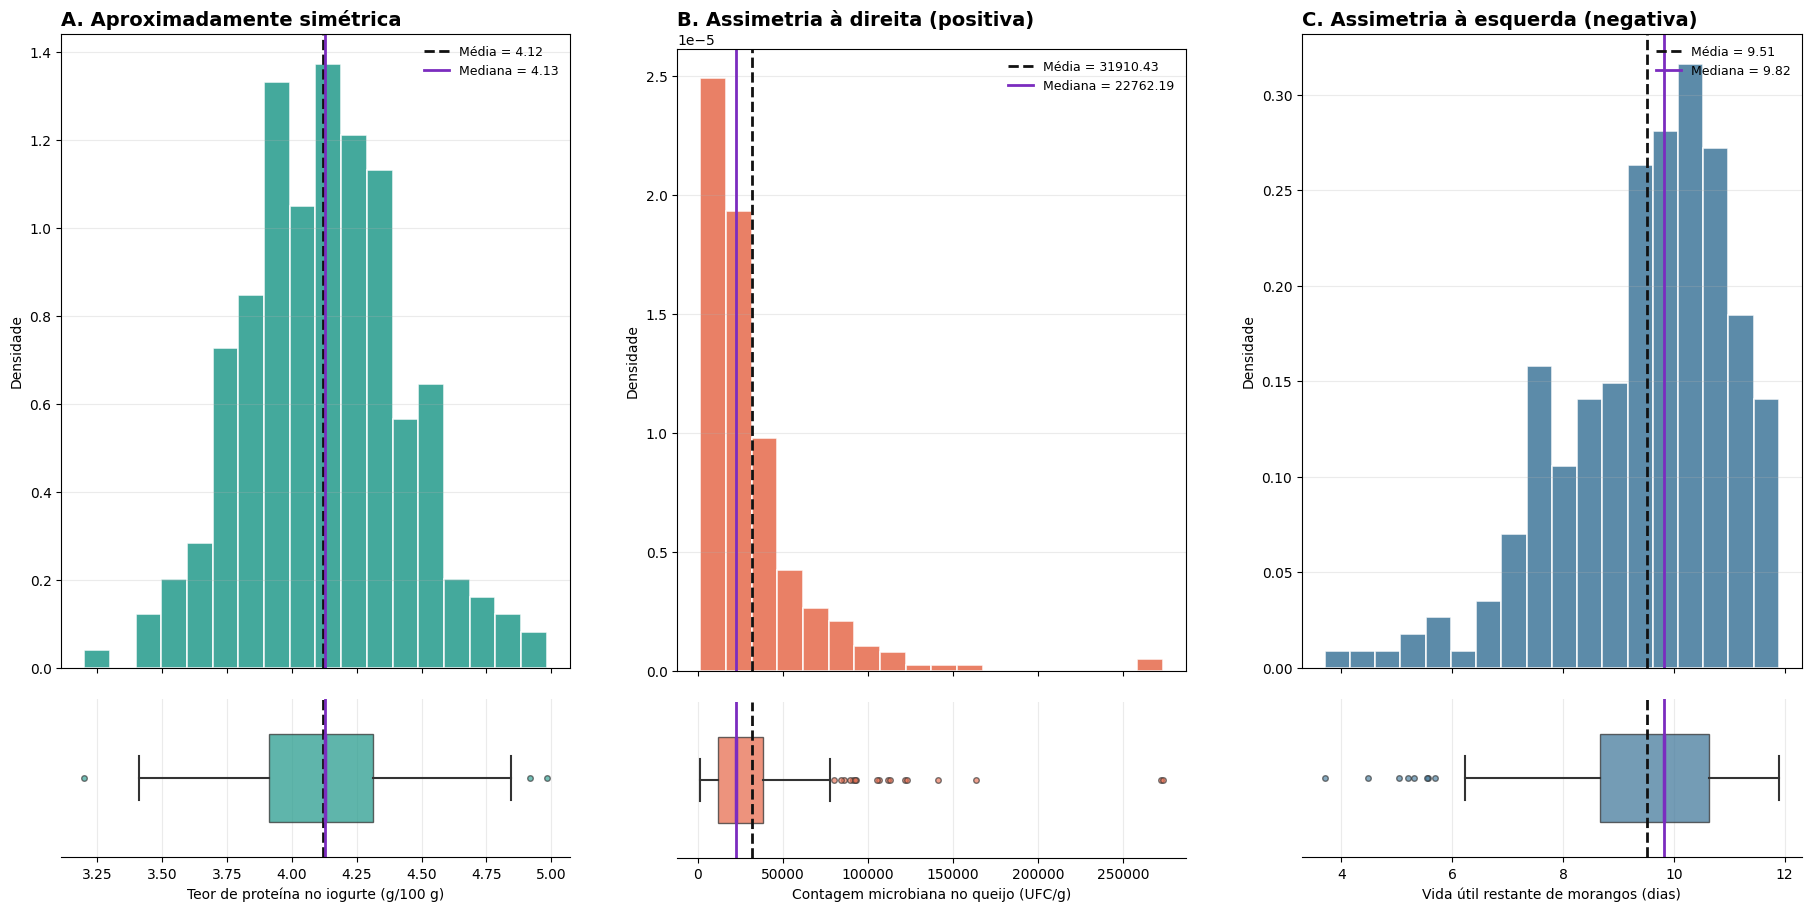

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew

# -----------------------------------------------------------------------------
# 1. Reprodutibilidade
# -----------------------------------------------------------------------------
rng = np.random.default_rng(2026)

# Número de amostras simuladas em cada cenário
n = 250

# -----------------------------------------------------------------------------
# 2. Dados simulados da área de alimentos
# -----------------------------------------------------------------------------

# A) Distribuição aproximadamente simétrica
# Teor de proteína em iogurte natural (g/100 g)
proteina_iogurte = rng.normal(loc=4.1, scale=0.28, size=n)
proteina_iogurte = np.clip(proteina_iogurte, 3.2, 5.0)

# B) Distribuição assimétrica à direita
# Contagem microbiana em queijo fresco (UFC/g)
#
# A maioria das amostras possui contagens moderadas, mas algumas
# podem apresentar contaminação muito maior, formando uma cauda à direita.
contagem_queijo = rng.lognormal(
    mean=np.log(2.2e4),
    sigma=0.85,
    size=n
)
contagem_queijo = np.clip(contagem_queijo, 1e3, 4.0e5)

# C) Distribuição assimétrica à esquerda
# Vida útil restante de morangos armazenados (dias)
#
# A maior parte dos lotes está próxima da vida útil máxima,
# mas alguns deterioram precocemente, formando cauda à esquerda.
vida_util_morango = 12 - rng.gamma(
    shape=2.2,
    scale=1.1,
    size=n
)
vida_util_morango = np.clip(vida_util_morango, 1.0, 12.0)

# -----------------------------------------------------------------------------
# 3. Organização das informações para os três gráficos
# -----------------------------------------------------------------------------
conjuntos = [
    {
        "dados": proteina_iogurte,
        "titulo": "A. Aproximadamente simétrica",
        "rotulo": "Teor de proteína no iogurte (g/100 g)",
        "cor": "#2A9D8F",
        "interpretacao": "Média e mediana tendem a ser semelhantes."
    },
    {
        "dados": contagem_queijo,
        "titulo": "B. Assimetria à direita (positiva)",
        "rotulo": "Contagem microbiana no queijo (UFC/g)",
        "cor": "#E76F51",
        "interpretacao": (
            "Cauda longa para valores altos; "
            "a média tende a exceder a mediana."
        )
    },
    {
        "dados": vida_util_morango,
        "titulo": "C. Assimetria à esquerda (negativa)",
        "rotulo": "Vida útil restante de morangos (dias)",
        "cor": "#457B9D",
        "interpretacao": (
            "Cauda longa para valores baixos; "
            "a média tende a ser inferior à mediana."
        )
    }
]

# -----------------------------------------------------------------------------
# 4. Construção dos gráficos
# -----------------------------------------------------------------------------
fig = plt.figure(figsize=(18, 9), layout="constrained")

# Cria três grandes painéis lado a lado
subfigs = fig.subfigures(
    nrows=1,
    ncols=3,
    wspace=0.08
)

for subfig, item in zip(subfigs, conjuntos):

    dados = item["dados"]

    # Estatísticas descritivas
    media = np.mean(dados)
    mediana = np.median(dados)
    coef_assimetria = skew(dados, bias=False)

    # Em cada painel: histograma em cima e boxplot embaixo
    gs = subfig.add_gridspec(
        nrows=2,
        ncols=1,
        height_ratios=[4, 1],
        hspace=0.05
    )

    ax_hist = subfig.add_subplot(gs[0])
    ax_box = subfig.add_subplot(gs[1], sharex=ax_hist)

    # -------------------------------------------------------------------------
    # Histograma
    # -------------------------------------------------------------------------
    ax_hist.hist(
        dados,
        bins=18,
        density=True,
        color=item["cor"],
        edgecolor="white",
        linewidth=1.2,
        alpha=0.88
    )

    # Linha pontilhada: média
    ax_hist.axvline(
        media,
        color="#111111",
        linewidth=2,
        linestyle="--",
        label=f"Média = {media:.2f}"
    )

    # Linha contínua: mediana
    ax_hist.axvline(
        mediana,
        color="#7B2CBF",
        linewidth=2,
        linestyle="-",
        label=f"Mediana = {mediana:.2f}"
    )

    ax_hist.set_title(
        item["titulo"],
        loc="left",
        fontsize=14,
        fontweight="bold"
    )

    ax_hist.set_ylabel("Densidade")
    ax_hist.grid(axis="y", alpha=0.25)
    ax_hist.tick_params(axis="x", labelbottom=False)

    ax_hist.legend(
        frameon=False,
        fontsize=9,
        loc="upper right"
    )



    # -------------------------------------------------------------------------
    # Boxplot horizontal
    # -------------------------------------------------------------------------
    ax_box.boxplot(
        dados,
        vert=False,
        widths=0.55,
        patch_artist=True,
        boxprops=dict(
            facecolor=item["cor"],
            alpha=0.75,
            edgecolor="#333333"
        ),
        medianprops=dict(
            color="#7B2CBF",
            linewidth=2.5
        ),
        whiskerprops=dict(
            color="#333333",
            linewidth=1.5
        ),
        capprops=dict(
            color="#333333",
            linewidth=1.5
        ),
        flierprops=dict(
            marker="o",
            markerfacecolor=item["cor"],
            markeredgecolor="#333333",
            markersize=4,
            alpha=0.65
        )
    )

    # Linhas de média e mediana também no boxplot
    ax_box.axvline(
        media,
        color="#111111",
        linewidth=2,
        linestyle="--"
    )

    ax_box.axvline(
        mediana,
        color="#7B2CBF",
        linewidth=2,
        linestyle="-"
    )

    ax_box.set_yticks([])
    ax_box.set_xlabel(item["rotulo"])
    ax_box.grid(axis="x", alpha=0.25)

    # Remove bordas desnecessárias
    ax_box.spines[["left", "right", "top"]].set_visible(False)

plt.show()

# Para salvar a figura em alta resolução, descomente esta linha
# antes de plt.show():
#
# fig.savefig(
#     "simetria_assimetria_alimentos.png",
#     dpi=300,
#     bbox_inches="tight"
# )

# Aproximadamente simétrica

In [28]:
import numpy as np
from scipy import stats


item = conjuntos[0]
dados = item["dados"]
titulo = item["titulo"]
rotulo = item["rotulo"]
interpretacao_geral = item["interpretacao"]

print(f"\n--- Análise para: {titulo} ({rotulo}) ---")

# Média
media = np.mean(dados)
print(f"Média: {media:.2f}")

# Mediana
mediana = np.median(dados)
print(f"Mediana: {mediana:.2f}")

# Moda (considerando o valor mais frequente)
mode_result = stats.mode(dados, keepdims=True)
if mode_result.count.size > 0:
    moda = mode_result.mode[0]
    print(f"Moda: {moda:.2f} (ocorrências: {mode_result.count[0]}) ")
else:
    moda = np.nan
    print("Moda: Não há um valor único mais frequente (ou dados contínuos sem repetições exatas).")

# Variância (amostral, ddof=1)
variancia = np.var(dados, ddof=1)
print(f"Variância: {variancia:.2f}")

# Desvio Padrão (amostral, ddof=1)
desvio_padrao = np.std(dados, ddof=1)
print(f"Desvio Padrão: {desvio_padrao:.2f}")

# Coeficiente de Variação
if media != 0:
    coef_variacao = (desvio_padrao / media) * 100
    print(f"Coeficiente de Variação: {coef_variacao:.2f}%")
else:
    print("Coeficiente de Variação: Indefinido (Média é zero).")

# Quartil 1 (25º percentil)
q1 = np.percentile(dados, 25)
print(f"Quartil 1 (Q1): {q1:.2f}")

# Quartil 3 (75º percentil)
q3 = np.percentile(dados, 75)
print(f"Quartil 3 (Q3): {q3:.2f}")

# Amplitude Interquartílica (IQR)
iqr = q3 - q1
print(f"Amplitude Interquartílica (IQR): {iqr:.2f}")

# Amplitude (Máximo - Mínimo)
amplitude = np.max(dados) - np.min(dados)
print(f"Amplitude: {amplitude:.2f}")



--- Análise para: A. Aproximadamente simétrica (Teor de proteína no iogurte (g/100 g)) ---
Média: 4.12
Mediana: 4.13
Moda: 3.20 (ocorrências: 1) 
Variância: 0.09
Desvio Padrão: 0.30
Coeficiente de Variação: 7.21%
Quartil 1 (Q1): 3.91
Quartil 3 (Q3): 4.31
Amplitude Interquartílica (IQR): 0.40
Amplitude: 1.78


In [29]:
# Interpretação
print(f" Observa-se que a média ({media:.2f}) e a mediana ({mediana:.2f}) são bem próximas, \n indicando uma distribuição simétrica ou quase simétrica, conforme esperado. A moda ({moda:.2f}) também está próxima. \nA amplitude interquartílica e o desvio padrão fornecem uma medida da dispersão dos dados em torno do centro.")

 Observa-se que a média (4.12) e a mediana (4.13) são bem próximas, 
 indicando uma distribuição simétrica ou quase simétrica, conforme esperado. A moda (3.20) também está próxima. 
A amplitude interquartílica e o desvio padrão fornecem uma medida da dispersão dos dados em torno do centro.


# Assimetria à direita (positiva)

In [30]:

item = conjuntos[1]
dados = item["dados"]
titulo = item["titulo"]
rotulo = item["rotulo"]
interpretacao_geral = item["interpretacao"]

print(f"\n--- Análise para: {titulo} ({rotulo}) ---")

# Média
media = np.mean(dados)
print(f"Média: {media:.2f}")

# Mediana
mediana = np.median(dados)
print(f"Mediana: {mediana:.2f}")

# Moda (considerando o valor mais frequente)
mode_result = stats.mode(dados, keepdims=True)
if mode_result.count.size > 0:
    moda = mode_result.mode[0]
    print(f"Moda: {moda:.2f} (ocorrências: {mode_result.count[0]}) ")
else:
    moda = np.nan
    print("Moda: Não há um valor único mais frequente (ou dados contínuos sem repetições exatas).")

# Variância (amostral, ddof=1)
variancia = np.var(dados, ddof=1)
print(f"Variância: {variancia:.2f}")

# Desvio Padrão (amostral, ddof=1)
desvio_padrao = np.std(dados, ddof=1)
print(f"Desvio Padrão: {desvio_padrao:.2f}")

# Coeficiente de Variação
if media != 0:
    coef_variacao = (desvio_padrao / media) * 100
    print(f"Coeficiente de Variação: {coef_variacao:.2f}%")
else:
    print("Coeficiente de Variação: Indefinido (Média é zero).")

# Quartil 1 (25º percentil)
q1 = np.percentile(dados, 25)
print(f"Quartil 1 (Q1): {q1:.2f}")

# Quartil 3 (75º percentil)
q3 = np.percentile(dados, 75)
print(f"Quartil 3 (Q3): {q3:.2f}")

# Amplitude Interquartílica (IQR)
iqr = q3 - q1
print(f"Amplitude Interquartílica (IQR): {iqr:.2f}")

# Amplitude (Máximo - Mínimo)
amplitude = np.max(dados) - np.min(dados)
print(f"Amplitude: {amplitude:.2f}")




--- Análise para: B. Assimetria à direita (positiva) (Contagem microbiana no queijo (UFC/g)) ---
Média: 31910.43
Mediana: 22762.19
Moda: 1562.57 (ocorrências: 1) 
Variância: 1171274080.93
Desvio Padrão: 34223.88
Coeficiente de Variação: 107.25%
Quartil 1 (Q1): 11891.01
Quartil 3 (Q3): 38407.55
Amplitude Interquartílica (IQR): 26516.54
Amplitude: 271788.73


In [31]:
# Interpretação
print(f" A média ({media:.2f}) é maior que a mediana ({mediana:.2f}), confirmando a assimetria positiva (à direita). \nIsso sugere a presença de valores altos (cauda à direita) que puxam a média para cima. \nA moda ({moda:.2f}) é o menor dos três. O alto desvio padrão e coeficiente de variação \nindicam uma dispersão considerável, especialmente em direção a valores maiores.")

 A média (31910.43) é maior que a mediana (22762.19), confirmando a assimetria positiva (à direita). 
Isso sugere a presença de valores altos (cauda à direita) que puxam a média para cima. 
A moda (1562.57) é o menor dos três. O alto desvio padrão e coeficiente de variação 
indicam uma dispersão considerável, especialmente em direção a valores maiores.


# Assimetria à esquerda (negativa)

In [32]:

item = conjuntos[2]
dados = item["dados"]
titulo = item["titulo"]
rotulo = item["rotulo"]
interpretacao_geral = item["interpretacao"]

print(f"\n--- Análise para: {titulo} ({rotulo}) ---")

# Média
media = np.mean(dados)
print(f"Média: {media:.2f}")

# Mediana
mediana = np.median(dados)
print(f"Mediana: {mediana:.2f}")

# Moda (considerando o valor mais frequente)
mode_result = stats.mode(dados, keepdims=True)
if mode_result.count.size > 0:
    moda = mode_result.mode[0]
    print(f"Moda: {moda:.2f} (ocorrências: {mode_result.count[0]}) ")
else:
    moda = np.nan
    print("Moda: Não há um valor único mais frequente (ou dados contínuos sem repetições exatas).")

# Variância (amostral, ddof=1)
variancia = np.var(dados, ddof=1)
print(f"Variância: {variancia:.2f}")

# Desvio Padrão (amostral, ddof=1)
desvio_padrao = np.std(dados, ddof=1)
print(f"Desvio Padrão: {desvio_padrao:.2f}")

# Coeficiente de Variação
if media != 0:
    coef_variacao = (desvio_padrao / media) * 100
    print(f"Coeficiente de Variação: {coef_variacao:.2f}%")
else:
    print("Coeficiente de Variação: Indefinido (Média é zero).")

# Quartil 1 (25º percentil)
q1 = np.percentile(dados, 25)
print(f"Quartil 1 (Q1): {q1:.2f}")

# Quartil 3 (75º percentil)
q3 = np.percentile(dados, 75)
print(f"Quartil 3 (Q3): {q3:.2f}")

# Amplitude Interquartílica (IQR)
iqr = q3 - q1
print(f"Amplitude Interquartílica (IQR): {iqr:.2f}")

# Amplitude (Máximo - Mínimo)
amplitude = np.max(dados) - np.min(dados)
print(f"Amplitude: {amplitude:.2f}")




--- Análise para: C. Assimetria à esquerda (negativa) (Vida útil restante de morangos (dias)) ---
Média: 9.51
Mediana: 9.82
Moda: 3.70 (ocorrências: 1) 
Variância: 2.32
Desvio Padrão: 1.52
Coeficiente de Variação: 16.03%
Quartil 1 (Q1): 8.66
Quartil 3 (Q3): 10.63
Amplitude Interquartílica (IQR): 1.97
Amplitude: 8.20


In [33]:
# Interpretação
print(f" A média ({media:.2f}) é menor que a mediana ({mediana:.2f}), indicando assimetria negativa (à esquerda). \nIsso é devido a valores baixos (cauda à esquerda) que puxam a média para baixo. A moda ({moda:.2f}) é o maior dos três.\n O desvio padrão e o coeficiente de variação quantificam a dispersão, com uma concentração de dados em valores \nmais altos e uma cauda estendida para valores mais baixos.")

 A média (9.51) é menor que a mediana (9.82), indicando assimetria negativa (à esquerda). 
Isso é devido a valores baixos (cauda à esquerda) que puxam a média para baixo. A moda (3.70) é o maior dos três.
 O desvio padrão e o coeficiente de variação quantificam a dispersão, com uma concentração de dados em valores 
mais altos e uma cauda estendida para valores mais baixos.
